<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter04_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (1).ttf


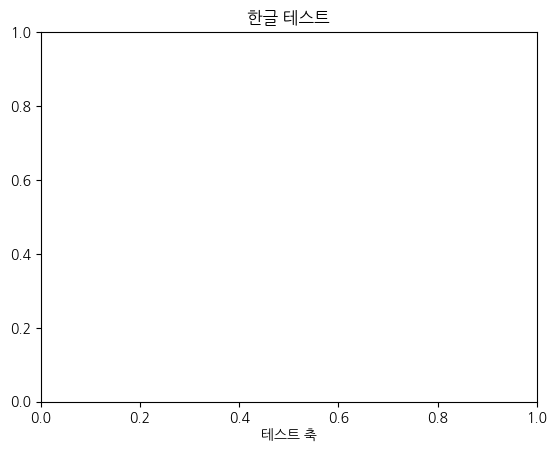

In [4]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

### 스태킹 앙상블 (Stacking Ensemble)

In [25]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

In [7]:
cancer_data = load_breast_cancer()
X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_label, test_size=0.2, random_state=0
)
print(f'학습셋: {X_train.shape}, 테스트셋: {X_test.shape}')

학습셋: (455, 30), 테스트셋: (114, 30)


In [9]:
#기반 모델 4개 정의
knn_clf = KNeighborsClassifier(n_neighbors=4) #KNN: 거리 기반 분류 (k=4 가장 가까운 4개 이웃으로 다수결)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0) #RandomForest: 100개 결정 트리의 다수결
dt_clf = DecisionTreeClassifier() #DecisionTree: 단일 결정 트리(상대적으로 약한 모델)
ada_clf = AdaBoostClassifier(n_estimators=100) #적응형(Adaptive)부스팅: 앞선 모델이 틀린 데이터에 대해 가중치(Weight)를 부여하여 그 다음 모델이 그 데이터를 더 잘 맞추도록 유도
#약한 분류기(깊이가 1인 결정 트리)를 순차적으로 결합(오분류 샘플에 더 집중)

#메타 모델(최종 예측기)
lr_final = LogisticRegression(C=10) #C=10: 규제 강도 역수(클수록 규제 약함)

In [11]:
#기반 모델 4개 학습(원본 학습 데이터로)
for clf in [knn_clf, rf_clf, dt_clf, ada_clf]:
    clf.fit(X_train, y_train)

In [13]:
#기본 스태킹: 개별 예측 -> 메타 모델 입력
#각 기반 모델로 테스트셋 예측
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)
#개별 모델 성능 확인
for name, pred in [('KNN',knn_pred), ('RF',rf_pred), ('DT',dt_pred), ('ADA',ada_pred)]:
  print(f'{name:4}: 정확도 = {accuracy_score(y_test, pred):.4f}')

KNN : 정확도 = 0.9211
RF  : 정확도 = 0.9649
DT  : 정확도 = 0.9123
ADA : 정확도 = 0.9737


In [17]:
pred = np.array([knn_pred, rf_pred,dt_pred, ada_pred]) #4개의 모델의 정확도
pred = np.transpose(pred) #전치행렬T (행과 열 교환)
print(pred.shape) #메타 모델입력 형태

(114, 4)


In [20]:
lr_final.fit(pred, y_test) #메타 모델이 테스트셋 레이블(y_test)을 직접 학습. Data Leakage 데이터 누수 발생
final_pred = lr_final.predict(pred) #4개의 기반 모델의 정확도
print(f"[기본 스태킹] 정확도 = {accuracy_score(y_test, final_pred):.4f}")
#실제 환경에서 이 성능은 재현 불가능, 문제점: 기반 모델과 메타 모델 모두 테스트셋 사용

[기본 스태킹] 정확도 = 0.9737


In [29]:
#CV 기반 스태킹
#기반 모델이 "자기가 학습한 적 없는 데이터"를 예측하도록 설계(교차 검증에서 검증 폴드는 학습에 사용되지 않은 데이터)
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
  kf = KFold(n_splits=n_folds, shuffle=False) #데이터 순서 유지(시계열 데이터에서 중요)
  meta_train_fold_pred = np.zeros((X_train_n.shape[0],1)) #메타모델 학습셋
  meta_test_pred = np.zeros((X_test_n.shape[0], n_folds)) #메타모델 테스트셋: 폴드별 테스트 예측 저장(나중에 평균 냄)
  print(f"{model.__class__.__name__} 시작")
  for fold_cnt, (train_idx,valid_idx) in enumerate(kf.split(X_train_n)):
    print(f'폴드{fold_cnt}',end='')
    #폴드별 학습/검증 데이터 분리
    X_tr=X_train_n[train_idx]
    y_tr=y_train_n[train_idx]
    X_va=X_train_n[valid_idx]

    #기반 모델을 학습 폴드로 학습
    model.fit(X_tr,y_tr)

    #검증 폴드 예측 -> 메타 학습셋의 해당 인덱스에 저장
    meta_train_fold_pred[valid_idx, :] = model.predict(X_va).reshape(-1,1)

    #전체 데이터셋 예측 -> 현재 폴드 컬럼에 저장
    meta_test_pred[:,fold_cnt]=model.predict(X_test_n)

    print(f"완료(검증셋 {len(valid_idx)}개), {meta_test_pred.shape}")

  #테스트 예측 = K개 폴드 예측의 평균(앙상블 효과)
  meta_test_pred_mean = np.mean(meta_test_pred, axis=1).reshape(-1,1)
  print(f" -> 메타 학습셋 shape: {meta_train_fold_pred.shape}")
  print(f" -> 메타 테스트셋 shape: {meta_test_pred_mean.shape}")
  print()
  return meta_train_fold_pred, meta_test_pred_mean

In [30]:
#각 기반 모델의 CV 예측 데이터 생성
knn_tr, knn_ts = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test,7)
rf_tr, rf_ts = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test,7)
dt_tr, dt_ts = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test,7)
ada_tr, ada_ts = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test,7)

KNeighborsClassifier 시작
폴드0완료(검증셋 65개), (114, 7)
폴드1완료(검증셋 65개), (114, 7)
폴드2완료(검증셋 65개), (114, 7)
폴드3완료(검증셋 65개), (114, 7)
폴드4완료(검증셋 65개), (114, 7)
폴드5완료(검증셋 65개), (114, 7)
폴드6완료(검증셋 65개), (114, 7)
 -> 메타 학습셋 shape: (455, 1)
 -> 메타 테스트셋 shape: (114, 1)

RandomForestClassifier 시작
폴드0완료(검증셋 65개), (114, 7)
폴드1완료(검증셋 65개), (114, 7)
폴드2완료(검증셋 65개), (114, 7)
폴드3완료(검증셋 65개), (114, 7)
폴드4완료(검증셋 65개), (114, 7)
폴드5완료(검증셋 65개), (114, 7)
폴드6완료(검증셋 65개), (114, 7)
 -> 메타 학습셋 shape: (455, 1)
 -> 메타 테스트셋 shape: (114, 1)

DecisionTreeClassifier 시작
폴드0완료(검증셋 65개), (114, 7)
폴드1완료(검증셋 65개), (114, 7)
폴드2완료(검증셋 65개), (114, 7)
폴드3완료(검증셋 65개), (114, 7)
폴드4완료(검증셋 65개), (114, 7)
폴드5완료(검증셋 65개), (114, 7)
폴드6완료(검증셋 65개), (114, 7)
 -> 메타 학습셋 shape: (455, 1)
 -> 메타 테스트셋 shape: (114, 1)

AdaBoostClassifier 시작
폴드0완료(검증셋 65개), (114, 7)
폴드1완료(검증셋 65개), (114, 7)
폴드2완료(검증셋 65개), (114, 7)
폴드3완료(검증셋 65개), (114, 7)
폴드4완료(검증셋 65개), (114, 7)
폴드5완료(검증셋 65개), (114, 7)
폴드6완료(검증셋 65개), (114, 7)
 -> 메타 학습셋 shape: (455, 1)
 -> 메타 

In [31]:
#4개 기반 모델의 CV 예측을 열 방향으로 합산
Stack_final_X_train = np.concatenate((knn_tr, rf_tr, dt_tr, ada_tr),axis=1) #열 방향으로 이어붙이기 -> (455,4)
Stack_final_X_test = np.concatenate((knn_ts, rf_ts, dt_ts, ada_ts),axis=1) #열 방향으로 이어붙이기 -> (114,4)

In [32]:
#메타 모델 학습
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)
print('===[CV 기반 스태킹] 최종 결과===')
print(f"정확도: {accuracy_score(y_test, stack_final):.4f}")

===[CV 기반 스태킹] 최종 결과===
정확도: 0.9649
